# Experiment: Single Dot

Single independently-controlled dot on a 64×64 white canvas.  
Loads results from `results/baseline/` and plots:
- Train / eval loss curves
- Latent geometry over training (L2 norm, per-dim std, effective rank)
- Mean latent drift
- PC1 × PC2 scatter colored by true x / y position
- Final PCA spectrum

In [28]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml

CWD = Path(".").resolve()
EXPERIMENT_DIR = CWD if (CWD / "config.yaml").exists() else CWD / "experiments" / "single_dot"
REPO_ROOT = EXPERIMENT_DIR.parent.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from misc.plot_style import FULL_WIDTH, HALF_WIDTH, palette, apply_matplotlib_style, figure_size
apply_matplotlib_style()

RESULTS_DIR = EXPERIMENT_DIR / "results" / "baseline"

HAS_RESULTS = RESULTS_DIR.exists()
if not HAS_RESULTS:
    print(f"No results found at {RESULTS_DIR}. Run train.py first.")
else:
    history = torch.load(RESULTS_DIR / "train_history.pt", map_location="cpu", weights_only=False)
    embeddings = torch.load(RESULTS_DIR / "embeddings.pt", map_location="cpu", weights_only=False)
    with open(RESULTS_DIR / "config.yaml") as f:
        cfg = yaml.safe_load(f)
    LATENT_DIM = int(cfg["model"]["latent_dim"])
    print(f"Loaded results from {RESULTS_DIR}")
    print(f"latent_dim={LATENT_DIM}, epochs={history['train']['epoch'][-1]}")

Loaded results from experiments/single_dot/results/baseline
latent_dim=64, epochs=100


In [29]:
def to_numpy(x):
    return x.detach().cpu().numpy() if isinstance(x, torch.Tensor) else np.asarray(x)

def smooth(values, window=5):
    return pd.Series(np.asarray(values, dtype=float)).rolling(window, min_periods=1).mean().to_numpy()

def pca_eigvals(Z, eps=1e-12):
    Zc = Z - Z.mean(axis=0)
    _, S, _ = np.linalg.svd(Zc, full_matrices=False)
    return np.maximum((S ** 2) / max(1, Z.shape[0] - 1), eps)

def effective_rank(eigvals, eps=1e-12):
    e = eigvals[eigvals > eps]
    if e.size == 0:
        return 1.0
    p = e / e.sum()
    return float(np.exp(-(p * np.log(p)).sum()))

def pca_2d(Z):
    Zc = Z - Z.mean(axis=0)
    _, S, Vt = np.linalg.svd(Zc, full_matrices=False)
    scores = Zc @ Vt[:2].T
    evr = (S ** 2) / max(1, Z.shape[0] - 1)
    evr /= np.maximum(evr.sum(), 1e-12)
    return scores, evr[:2]

def snapshot_metrics(snap):
    Z = np.concatenate([to_numpy(snap["z_t"]), to_numpy(snap["z_tp1"])], axis=0)
    eigvals = pca_eigvals(Z)
    return {
        "z_l2": float(np.linalg.norm(Z, axis=1).mean()),
        "z_std": float(Z.std(axis=0, ddof=0).mean()),
        "z_eff_rank": effective_rank(eigvals),
        "mean_z_l2": float(np.linalg.norm(Z.mean(axis=0))),
        "eigvals": eigvals,
    }

if HAS_RESULTS:
    metrics = {int(e): snapshot_metrics(s) for e, s in embeddings["snapshots"].items()}
    snap_epochs = sorted(metrics.keys())

## Loss Curves

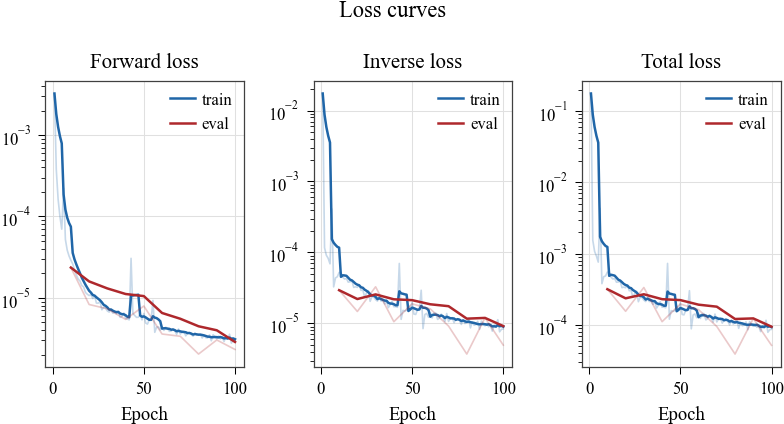

In [30]:
if not HAS_RESULTS:
    print("No results.")
else:
    train_h = history["train"]
    eval_h  = history["eval"]

    fig, axes = plt.subplots(1, 3, figsize=figure_size(FULL_WIDTH, ratio=0.55))
    fig.suptitle("Loss curves")

    for ax, key, title in zip(axes, ["fwd", "inv", "total"],
                              ["Forward loss", "Inverse loss", "Total loss"]):
        ax.semilogy(train_h["epoch"], train_h[key], color=palette["Dark Blue"], alpha=0.25, linewidth=0.8)
        ax.semilogy(train_h["epoch"], smooth(train_h[key]), color=palette["Dark Blue"], label="train")
        ax.semilogy(eval_h["epoch"], eval_h[key], color=palette["Dark Red"], alpha=0.25, linewidth=0.8)
        ax.semilogy(eval_h["epoch"], smooth(eval_h[key]), color=palette["Dark Red"], label="eval")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.grid(True)
        ax.legend()

    fig.tight_layout()
    plt.show()

## Latent Geometry

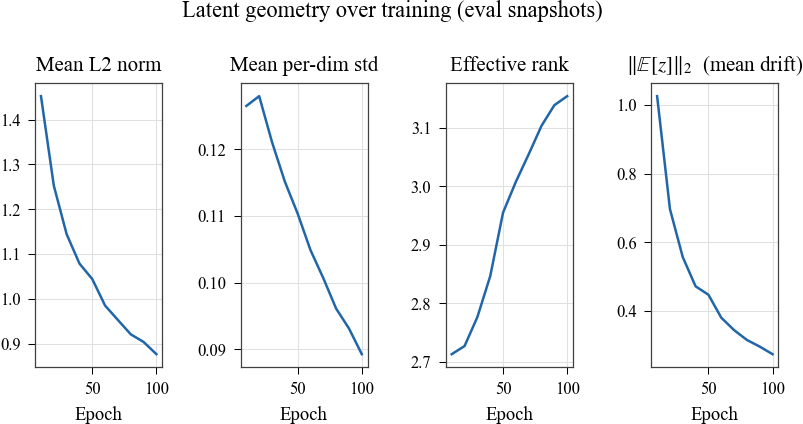

In [31]:
if not HAS_RESULTS:
    print("No results.")
else:
    fig, axes = plt.subplots(1, 4, figsize=figure_size(FULL_WIDTH, ratio=0.55))
    fig.suptitle("Latent geometry over training (eval snapshots)")

    specs = [
        ("z_l2",       "Mean L2 norm"),
        ("z_std",      "Mean per-dim std"),
        ("z_eff_rank", "Effective rank"),
        ("mean_z_l2",  r"$\|\mathbb{E}[z]\|_2$  (mean drift)"),
    ]

    for ax, (key, title) in zip(axes, specs):
        values = [metrics[e][key] for e in snap_epochs]
        ax.plot(snap_epochs, values, color=palette["Dark Blue"])
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.grid(True)

    fig.tight_layout()
    plt.show()

## Final PCA Spectrum

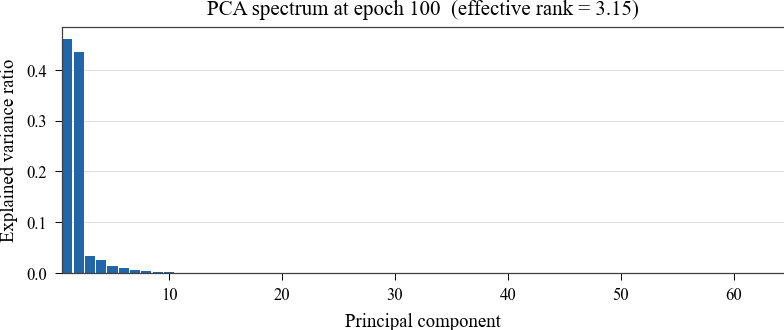

In [32]:
if not HAS_RESULTS:
    print("No results.")
else:
    last_epoch = max(snap_epochs)
    eigvals = metrics[last_epoch]["eigvals"]
    evr = eigvals / np.maximum(eigvals.sum(), 1e-12)
    erank = metrics[last_epoch]["z_eff_rank"]

    fig, ax = plt.subplots(figsize=figure_size(FULL_WIDTH, ratio=0.45))
    ax.bar(np.arange(1, len(evr) + 1), evr, color=palette["Dark Blue"], width=0.9)
    ax.set_xlim(0.5, LATENT_DIM + 0.5)
    ax.set_title(f"PCA spectrum at epoch {last_epoch}  (effective rank = {erank:.2f})")
    ax.set_xlabel("Principal component")
    ax.set_ylabel("Explained variance ratio")
    ax.grid(True, axis="y")
    fig.tight_layout()
    plt.show()

## Position Grid → Latent Space

A 31×31 grid of initial dot positions (every 2 pixels from 2 to 62) is passed through the trained encoder.  
Left: world-state grid colored by a 2D HSV gradient (hue = x, brightness = y).  
Right: the same points in PC1 × PC2 space with identical colors — a clear topology-preserving map indicates the encoder has learned a well-structured position representation.

In [33]:
if not HAS_RESULTS:
    print("No results.")
else:
    from matplotlib.colors import hsv_to_rgb
    from models import CNNEncoder
    from datasets.structured_dot_world import render_dots, StructuredDotWorldConfig, DotGroup, MotionType

    # ── Load encoder ─────────────────────────────────────────────────────
    image_size = int(cfg.get("dataset", {}).get("image_size", 64))
    dot_radius = int(cfg.get("dataset", {}).get("dot_radius", 2))

    encoder = CNNEncoder(obs_channels=3, latent_dim=LATENT_DIM, image_size=image_size)
    ckpt = torch.load(RESULTS_DIR / "model.pt", map_location="cpu", weights_only=False)
    encoder.load_state_dict(ckpt["encoder"])
    encoder.eval()

    # ── Build position grid ───────────────────────────────────────────────
    grid_vals = np.arange(12, 53, 4)
    xi, yi   = np.meshgrid(grid_vals, grid_vals)
    xi_flat  = xi.ravel().astype(float)          # (N,)
    yi_flat  = yi.ravel().astype(float)

    # ── Render frames ─────────────────────────────────────────────────────
    dot_cfg = StructuredDotWorldConfig(
        groups=[DotGroup(motion_type=MotionType.INDEPENDENT, num_dots=1, color_indices=[0])],
        image_size=image_size,
        dot_radius=dot_radius,
    )
    frames  = np.stack([
        render_dots(np.array([[x, y]]), [0], dot_cfg)
        for x, y in zip(xi_flat, yi_flat)
    ])                                            # (N, 3, H, W)

    # ── Encode ────────────────────────────────────────────────────────────
    with torch.no_grad():
        z = encoder(torch.from_numpy(frames)).numpy()   # (N, latent_dim)


In [ ]:
if not HAS_RESULTS:
    print("No results.")
else:
    from torch.utils.data import DataLoader
    from datasets.structured_dot_world import StructuredDotWorldDataset
    from train import build_structured_config

    PCA_FIT_SAMPLES = min(10_000, int(cfg["dataset"].get("train_samples", 10_000)))
    PCA_FIT_BATCH_SIZE = 512

    structured_cfg = build_structured_config(cfg["dataset"])
    pca_fit_ds = StructuredDotWorldDataset(
        structured_cfg,
        num_samples=PCA_FIT_SAMPLES,
        seed=int(cfg["training"].get("seed", 42)),
    )
    pca_fit_loader = DataLoader(
        pca_fit_ds,
        batch_size=PCA_FIT_BATCH_SIZE,
        shuffle=False,
    )

    z_fit_chunks = []
    with torch.no_grad():
        for obs_t, _, obs_tp1, _ in pca_fit_loader:
            obs_pair = torch.cat([obs_t, obs_tp1], dim=0)
            z_fit_chunks.append(encoder(obs_pair).numpy())

    z_fit = np.concatenate(z_fit_chunks, axis=0)
    fit_mu = z_fit.mean(axis=0)
    fit_Zc = z_fit - fit_mu
    _, fit_S, fit_Vt = np.linalg.svd(fit_Zc, full_matrices=False)
    fit_evr = (fit_S ** 2) / max(1, z_fit.shape[0] - 1)
    fit_evr = fit_evr / np.maximum(fit_evr.sum(), 1e-12)

    _evr = fit_evr
    _sc2 = (z - fit_mu) @ fit_Vt[:2].T

    # 2-D custom colormap: bilinear interpolation between four corner colors.
    _xn = (xi_flat - xi_flat.min()) / np.maximum(xi_flat.max() - xi_flat.min(), 1e-12)
    _yn = (yi_flat - yi_flat.min()) / np.maximum(yi_flat.max() - yi_flat.min(), 1e-12)
    _xn = np.clip(_xn, 0.0, 1.0)
    _yn = np.clip(_yn, 0.0, 1.0)

    # Physical-state corners:
    # bottom-left  = blue
    # bottom-right = green
    # top-left     = red
    # top-right    = yellow
    _c_bl = np.array([0.10, 0.25, 0.90])  # blue
    _c_br = np.array([0.05, 0.62, 0.25])  # green
    _c_tl = np.array([0.85, 0.10, 0.10])  # red
    _c_tr = np.array([0.95, 0.78, 0.10])  # yellow

    _gc = (
        (1.0 - _xn)[:, None] * (1.0 - _yn)[:, None] * _c_bl
        + _xn[:, None] * (1.0 - _yn)[:, None] * _c_br
        + (1.0 - _xn)[:, None] * _yn[:, None] * _c_tl
        + _xn[:, None] * _yn[:, None] * _c_tr
    )
    _gc = np.clip(_gc, 0.0, 1.0)

    # -- Figure layout --------------------------------------------------------
    fig = plt.figure(figsize=figure_size(FULL_WIDTH, height=2.35))
    gs = fig.add_gridspec(
        1,
        3,
        width_ratios=[1.0, 1.0, 1.0],
        left=0.075,
        right=0.985,
        bottom=0.22,
        top=0.78,
        wspace=0.42,
    )

    ax_a = fig.add_subplot(gs[0, 0])
    ax_b = fig.add_subplot(gs[0, 1])
    ax_c = fig.add_subplot(gs[0, 2])

    # Keep all panels visually comparable.
    ax_a.set_box_aspect(1)
    ax_b.set_box_aspect(1)
    ax_c.set_box_aspect(1)

    # Panel titles: no (a)/(b)/(c), slightly closer to plots
    _title_y = 0.785
    for _ax, _title in [
        (ax_a, "PCA spectrum"),
        (ax_b, "World state grid"),
        (ax_c, "Encoded embeddings"),
    ]:
        _bbox = _ax.get_position()
        fig.text(
            0.5 * (_bbox.x0 + _bbox.x1),
            _title_y,
            _title,
            ha="center",
            va="bottom",
            fontsize=plt.rcParams["axes.titlesize"],
        )

    # -- 1) PCA spectrum ------------------------------------------------------
    _n = 15
    ax_a.bar(
        np.arange(1, _n + 1),
        _evr[:_n],
        color=palette["Dark Blue"],
        width=0.52,
        zorder=2,
    )
    ax_a.axvline(
        2.5,
        color=palette["Dark Red"],
        linestyle="--",
        linewidth=1.0,
        zorder=3,
        label="true dim=2",
    )

    ax_a.set_xlim(0.3, _n + 0.7)
    ax_a.set_ylim(0, max(0.05, 1.08 * np.max(_evr[:_n])))
    ax_a.set_xticks([1, 5, 10, 15])

    ax_a.set_xlabel("Principal component")
    ax_a.set_ylabel("Explained variance ratio")
    ax_a.legend(loc="upper right", handlelength=1.0, handletextpad=0.3, borderpad=0.25, fontsize=7)
    ax_a.grid(True, axis="y")

    # -- 2) World state grid --------------------------------------------------
    ax_b.scatter(
        xi_flat,
        yi_flat,
        c=_gc,
        s=14,
        linewidths=0,
        rasterized=True,
    )

    ax_b.set_xlabel("x")
    ax_b.set_ylabel("y")
    ax_b.set_aspect("equal", adjustable="box")
    ax_b.invert_yaxis()

    _ticks_xy = np.arange(10, 60, 10)
    ax_b.set_xticks([12,24,36,48])
    ax_b.set_yticks([12,24,36,48])
    ax_b.set_xlim(4,60)
    ax_b.set_ylim(4,60)
    # ax_b.grid(True)

    # -- 3) Encoded embeddings (2D: PC1 vs PC2) ------------------------------
    ax_c.scatter(
        _sc2[:, 0],
        _sc2[:, 1],
        c=_gc,
        s=10,
        linewidths=0,
        rasterized=True,
    )

    # Common symmetric limits and identical ticks on both axes
    _r = np.max(np.abs(_sc2))
    _r = max(_r, 1e-6)
    _r = np.ceil(2 * _r) / 2

    ax_c.set_xlim(-_r-0.2, _r+0.2)
    ax_c.set_ylim(-_r-0.2, _r+0.2)
    ax_c.set_aspect("equal", adjustable="box")

    _ticks_pc = np.linspace(-_r, _r, 5)
    ax_c.set_xticks(_ticks_pc)
    ax_c.set_yticks(_ticks_pc)

    ax_c.set_xlabel("PC1")
    ax_c.set_ylabel("PC2")
    # ax_c.grid(True)
    
    plt.show()

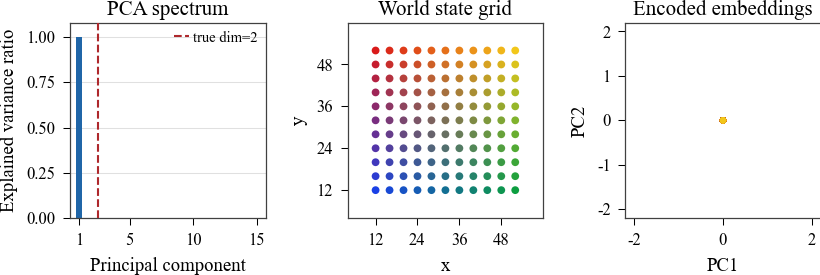

In [ ]:
if not HAS_RESULTS:
    print("No results.")
else:
    from models import CNNEncoder
    from torch.utils.data import DataLoader
    from datasets.structured_dot_world import StructuredDotWorldDataset
    from train import build_structured_config

    # Locate the lambda=0 ablation run.
    _lambda0 = None
    for _run_dir in sorted((EXPERIMENT_DIR / "results").iterdir()):
        if not (_run_dir.is_dir() and (_run_dir / "model.pt").exists() and (_run_dir / "config.yaml").exists()):
            continue
        with open(_run_dir / "config.yaml") as _f:
            _run_cfg = yaml.safe_load(_f)
        if np.isclose(float(_run_cfg.get("training", {}).get("lambda", float("nan"))), 0.0):
            _lambda0 = (_run_dir, _run_cfg)
            break

    if _lambda0 is None:
        print(f"No lambda=0 checkpoint found under {EXPERIMENT_DIR / 'results'}.")
    else:
        _lambda0_dir, _lambda0_cfg = _lambda0
        _latent_dim0 = int(_lambda0_cfg["model"]["latent_dim"])
        _image_size0 = int(_lambda0_cfg.get("dataset", {}).get("image_size", image_size))

        _encoder0 = CNNEncoder(obs_channels=3, latent_dim=_latent_dim0, image_size=_image_size0)
        _encoder0.load_state_dict(
            torch.load(_lambda0_dir / "model.pt", map_location="cpu", weights_only=False)["encoder"])
        _encoder0.eval()

        # Train-fit PCA: fit on training observations, then project the grid
        # (same methodology as the lambda>0 figure above).
        _fit_ds = StructuredDotWorldDataset(
            build_structured_config(_lambda0_cfg["dataset"]),
            num_samples=min(10_000, int(_lambda0_cfg["dataset"].get("train_samples", 10_000))),
            seed=int(_lambda0_cfg["training"].get("seed", 42)),
        )
        _fit_chunks = []
        with torch.no_grad():
            for _ot, _, _otp1, _ in DataLoader(_fit_ds, batch_size=512, shuffle=False):
                _fit_chunks.append(_encoder0(torch.cat([_ot, _otp1], dim=0)).numpy())
        _zfit0 = np.concatenate(_fit_chunks, axis=0)
        _fit_mu0 = _zfit0.mean(axis=0)
        _, _fitS0, _fitVt0 = np.linalg.svd(_zfit0 - _fit_mu0, full_matrices=False)
        _evr0 = (_fitS0 ** 2) / max(1, _zfit0.shape[0] - 1)
        _evr0 = _evr0 / np.maximum(_evr0.sum(), 1e-12)

        with torch.no_grad():
            _z0 = _encoder0(torch.from_numpy(frames)).numpy()
        _sc2_0 = (_z0 - _fit_mu0) @ _fitVt0[:2].T

        fig = plt.figure(figsize=figure_size(FULL_WIDTH, height=2.35))
        gs = fig.add_gridspec(
            1, 3, width_ratios=[1.0, 1.0, 1.0],
            left=0.075, right=0.985, bottom=0.22, top=0.78, wspace=0.42,
        )
        ax_a = fig.add_subplot(gs[0, 0])
        ax_b = fig.add_subplot(gs[0, 1])
        ax_c = fig.add_subplot(gs[0, 2])
        ax_a.set_box_aspect(1); ax_b.set_box_aspect(1); ax_c.set_box_aspect(1)

        _title_y = 0.785
        for _ax, _title in [(ax_a, "PCA spectrum"), (ax_b, "World state grid"), (ax_c, "Encoded embeddings")]:
            _bbox = _ax.get_position()
            fig.text(0.5 * (_bbox.x0 + _bbox.x1), _title_y, _title,
                     ha="center", va="bottom", fontsize=plt.rcParams["axes.titlesize"])

        _n = 15
        ax_a.bar(np.arange(1, _n + 1), _evr0[:_n], color=palette["Dark Blue"], width=0.52, zorder=2)
        ax_a.axvline(2.5, color=palette["Dark Red"], linestyle="--", linewidth=1.0, zorder=3, label="true dim=2")
        ax_a.set_xlim(0.3, _n + 0.7)
        ax_a.set_ylim(0, max(0.05, 1.08 * np.max(_evr0[:_n])))
        ax_a.set_xticks([1, 5, 10, 15])
        ax_a.set_xlabel("Principal component")
        ax_a.set_ylabel("Explained variance ratio")
        ax_a.legend(loc="upper right", handlelength=1.0, handletextpad=0.3, borderpad=0.25, fontsize=7)
        ax_a.grid(True, axis="y")

        ax_b.scatter(xi_flat, yi_flat, c=_gc, s=14, linewidths=0, rasterized=True)
        ax_b.set_xlabel("x"); ax_b.set_ylabel("y")
        ax_b.set_aspect("equal", adjustable="box")
        ax_b.invert_yaxis()
        ax_b.set_xticks([12, 24, 36, 48]); ax_b.set_yticks([12, 24, 36, 48])
        ax_b.set_xlim(4, 60); ax_b.set_ylim(4, 60)

        ax_c.scatter(_sc2_0[:, 0], _sc2_0[:, 1], c=_gc, s=10, linewidths=0, rasterized=True)
        ax_c.set_xlim(-2 - 0.2, 2 + 0.2)
        ax_c.set_ylim(-2 - 0.2, 2 + 0.2)
        ax_c.set_aspect("equal", adjustable="box")
        ax_c.set_xlabel("PC1"); ax_c.set_ylabel("PC2")

        plt.show()

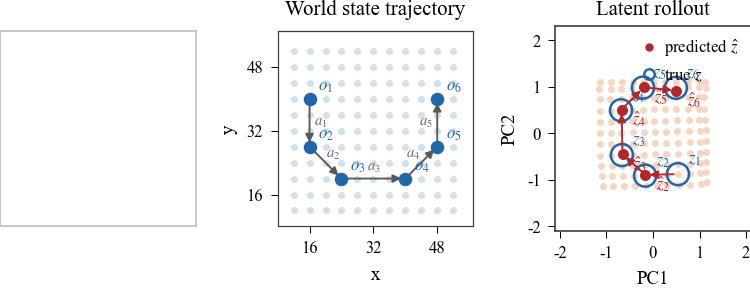

In [ ]:
if not HAS_RESULTS:
    print("No results.")
else:
    import matplotlib.lines as mlines
    from models import ForwardModel

    if "fit_mu" not in globals() or "fit_Vt" not in globals():
        from torch.utils.data import DataLoader
        from datasets.structured_dot_world import StructuredDotWorldDataset
        from train import build_structured_config

        PCA_FIT_SAMPLES = min(10_000, int(cfg["dataset"].get("train_samples", 10_000)))
        PCA_FIT_BATCH_SIZE = 512

        structured_cfg = build_structured_config(cfg["dataset"])
        pca_fit_ds = StructuredDotWorldDataset(
            structured_cfg,
            num_samples=PCA_FIT_SAMPLES,
            seed=int(cfg["training"].get("seed", 42)),
        )
        pca_fit_loader = DataLoader(
            pca_fit_ds,
            batch_size=PCA_FIT_BATCH_SIZE,
            shuffle=False,
        )

        z_fit_chunks = []
        with torch.no_grad():
            for obs_t, _, obs_tp1, _ in pca_fit_loader:
                obs_pair = torch.cat([obs_t, obs_tp1], dim=0)
                z_fit_chunks.append(encoder(obs_pair).numpy())

        z_fit = np.concatenate(z_fit_chunks, axis=0)
        fit_mu = z_fit.mean(axis=0)
        fit_Zc = z_fit - fit_mu
        _, fit_S, fit_Vt = np.linalg.svd(fit_Zc, full_matrices=False)
        fit_evr = (fit_S ** 2) / max(1, z_fit.shape[0] - 1)
        fit_evr = fit_evr / np.maximum(fit_evr.sum(), 1e-12)

    # -- 6-point smooth arc trajectory ---------------------------------------
    _traj_pts = [(18, 40), (18, 28), (26, 20), (42, 20), (50, 28), (50, 40)]
    N_WAY = len(_traj_pts)

    _blue = palette["Dark Blue"]
    _red = palette["Dark Red"]
    _max_disp = float(cfg.get("dataset", {}).get("max_displacement", 16))

    def _nearest(xi, yi, xt, yt):
        return int(np.argmin((xi - xt) ** 2 + (yi - yt) ** 2))

    _tidx = [_nearest(xi_flat, yi_flat, x, y) for x, y in _traj_pts]
    _txy = [(xi_flat[i], yi_flat[i]) for i in _tidx]

    _actions = [
        np.array(
            [
                _txy[k + 1][0] - _txy[k][0],
                _txy[k + 1][1] - _txy[k][1],
            ],
            dtype=np.float32,
        )
        / _max_disp
        for k in range(N_WAY - 1)
    ]

    _ckpt = torch.load(RESULTS_DIR / "model.pt", map_location="cpu", weights_only=False)
    _fwd_t = ForwardModel(
        latent_dim=LATENT_DIM,
        action_dim=2,
        hidden_dim=cfg.get("model", {}).get("hidden_dim", 256),
    )
    _fwd_t.load_state_dict(_ckpt["forward"])
    _fwd_t.eval()

    _z_true = z[_tidx]

    _z_roll = [z[[_tidx[0]]]]
    with torch.no_grad():
        for _a in _actions:
            _z_roll.append(
                _fwd_t(
                    torch.from_numpy(_z_roll[-1]),
                    torch.from_numpy(_a[None]),
                ).numpy()
            )

    _z_roll = np.concatenate(_z_roll, axis=0)

    # Project the latent grid and rollout onto PCA axes fitted on train data.
    _sc2 = (z - fit_mu) @ fit_Vt[:2].T
    _sc_tr = (_z_true - fit_mu) @ fit_Vt[:2].T
    _sc_rl = (_z_roll - fit_mu) @ fit_Vt[:2].T

    def _plabel(x1, y1, x2, y2, off=2.8):
        dx, dy = x2 - x1, y2 - y1
        n = max(np.hypot(dx, dy), 1e-9)
        return (x1 + x2) / 2 - dy / n * off, (y1 + y2) / 2 + dx / n * off

    _s = 14
    _arr = dict(arrowstyle="-|>", lw=0.9, mutation_scale=8)
    _ann_kw = dict(fontsize=7, ha="center", va="center")

    fig = plt.figure(figsize=figure_size(FULL_WIDTH, height=2.55))
    gs = fig.add_gridspec(
        1,
        3,
        width_ratios=[1.0, 1.0, 1.0],
        left=0.075,
        right=0.985,
        bottom=0.24,
        top=0.78,
        wspace=0.42,
    )

    ax_a = fig.add_subplot(gs[0, 0])
    ax_b = fig.add_subplot(gs[0, 1])
    ax_c = fig.add_subplot(gs[0, 2])

    ax_a.set_box_aspect(1)
    ax_b.set_box_aspect(1)
    ax_c.set_box_aspect(1)

    _title_y = 0.795
    for _ax, _title in [
        (ax_a, ""),
        (ax_b, "World state trajectory"),
        (ax_c, "Latent rollout"),
    ]:
        _bbox = _ax.get_position()
        fig.text(
            0.5 * (_bbox.x0 + _bbox.x1),
            _title_y,
            _title,
            ha="center",
            va="bottom",
            fontsize=plt.rcParams["axes.titlesize"],
        )

    ax_a.set_facecolor("white")
    for _sp in ax_a.spines.values():
        _sp.set_edgecolor("0.75")
        _sp.set_linewidth(0.8)

    ax_a.set_xlim(0, 1)
    ax_a.set_ylim(0, 1)
    ax_a.set_xticks([])
    ax_a.set_yticks([])

    # World state panel is unchanged from the original rollout plot.
    ax_b.scatter(
        xi_flat,
        yi_flat,
        color=palette["Light Blue"],
        s=_s * 0.8,
        linewidths=0,
        rasterized=True,
        zorder=1,
    )

    for k in range(N_WAY - 1):
        x1, y1 = _txy[k]
        x2, y2 = _txy[k + 1]

        ax_b.annotate(
            "",
            xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops=dict(**_arr, color="0.35"),
            zorder=4,
        )

        lx, ly = _plabel(x1, y1, x2, y2)
        ax_b.text(
            lx,
            ly,
            rf"$a_{{{k + 1}}}$",
            **_ann_kw,
            color="0.40",
            zorder=5,
        )

    for k, (x, y) in enumerate(_txy):
        ax_b.scatter(
            x,
            y,
            color=_blue,
            s=_s * 3,
            linewidths=0,
            zorder=5,
        )
        ax_b.annotate(
            rf"$o_{{{k + 1}}}$",
            (x, y),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
            color=_blue,
            zorder=6,
        )

    ax_b.set_xlim(8, 57)
    ax_b.set_ylim(57, 8)
    ax_b.set_aspect("equal", adjustable="box")
    ax_b.set_xticks([16, 32, 48])
    ax_b.set_yticks([16, 32, 48])
    ax_b.set_xlabel("x")
    ax_b.set_ylabel("y")
    ax_b.invert_yaxis()

    ax_c.scatter(
        _sc2[:, 0],
        _sc2[:, 1],
        color=palette["Light Red"],
        s=_s * 0.8,
        linewidths=0,
        rasterized=True,
        zorder=1,
    )

    for k in range(0, N_WAY):
        ax_c.scatter(
            _sc_tr[k, 0],
            _sc_tr[k, 1],
            facecolors="none",
            edgecolors=_blue,
            linewidths=1.2,
            s=_s * 8,
            zorder=3,
        )
        ax_c.annotate(
            rf"$z_{{{k + 1}}}$",
            (_sc_tr[k, 0], _sc_tr[k, 1]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
            color=_blue,
            zorder=4,
        )

    for k in range(N_WAY - 1):
        ax_c.annotate(
            "",
            xy=(_sc_rl[k + 1, 0], _sc_rl[k + 1, 1]),
            xytext=(_sc_rl[k, 0], _sc_rl[k, 1]),
            arrowprops=dict(**_arr, color=_red),
            zorder=5,
        )

    for k in range(1, N_WAY):
        ax_c.scatter(
            _sc_rl[k, 0],
            _sc_rl[k, 1],
            color=_red,
            s=_s * 2,
            linewidths=0,
            zorder=6,
        )
        ax_c.annotate(
            rf"$\hat{{z}}_{{{k + 1}}}$",
            (_sc_rl[k, 0], _sc_rl[k, 1]),
            xytext=(5, -7),
            textcoords="offset points",
            fontsize=8,
            color=_red,
            zorder=7,
        )

    _leg = [
        mlines.Line2D(
            [],
            [],
            color=_red,
            marker="o",
            markersize=3,
            linewidth=0,
            label=r"predicted $\hat{z}$",
        ),
        mlines.Line2D(
            [],
            [],
            color=_blue,
            marker="o",
            markersize=5,
            linewidth=0,
            markerfacecolor="none",
            markeredgewidth=1.2,
            label=r"true $z$",
        ),
    ]

    ax_c.legend(
        handles=_leg,
        loc="upper right",
        handlelength=1.0,
        borderaxespad=0.3,
    )

    ax_c.set_xlim(-2.1, 2.1)
    ax_c.set_ylim(-2.1, 2.3)
    ax_c.set_aspect("equal", adjustable="box")
    ax_c.set_xticks(np.linspace(-2, 2, 5))
    ax_c.set_yticks(np.linspace(-2, 2, 5))
    ax_c.set_xlabel("PC1")
    ax_c.set_ylabel("PC2")

    for side in ["left", "right", "top", "bottom"]:
        ax_c.spines[side].set_visible(True)
        ax_c.spines[side].set_linewidth(0.8)
        ax_c.spines[side].set_edgecolor("0.25")
        ax_c.spines[side].set_zorder(50)

    
    plt.show()